In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

REPO_URL = "https://github.com/SagarSharma131006/MediScan_Medical_Image_Classification.git"
PROJECT_DIR = Path("/content/MediScan_Medical_Image_Classification")

if not PROJECT_DIR.exists():
    !git clone {REPO_URL} {PROJECT_DIR}

os.chdir(PROJECT_DIR)
print("Current folder:", os.getcwd())

Mounted at /content/drive
Cloning into '/content/MediScan_Medical_Image_Classification'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 108 (delta 48), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (108/108), 2.25 MiB | 8.65 MiB/s, done.
Resolving deltas: 100% (48/48), done.
Current folder: /content/MediScan_Medical_Image_Classification


In [2]:
!pip install -q pandas numpy pillow matplotlib seaborn tqdm

In [3]:
from pathlib import Path

folders = [
    "data/raw",
    "data/processed",
    "notebooks",
    "src",
    "models",
    "reports",
    "figures"
]

for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Folders ready.")

Folders ready.


In [4]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/archive.zip")
extract_path = Path("data/raw")

if not zip_path.exists():
    raise FileNotFoundError("archive.zip Google Drive ke MyDrive folder me upload karo.")

if not (extract_path / "Training").exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

Dataset extracted successfully.


In [5]:
from pathlib import Path
import pandas as pd

image_paths = []
labels = []
splits = []

for split_folder in ["Training", "Testing"]:
    split_path = Path("data/raw") / split_folder

    for class_folder in split_path.iterdir():
        if class_folder.is_dir():
            for img_path in class_folder.glob("*"):
                if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                    image_paths.append(str(img_path))
                    labels.append(class_folder.name)
                    splits.append(split_folder)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels,
    "original_split": splits
})

df.to_csv("data/processed/day1_dataset_manifest.csv", index=False)

print("Total images:", len(df))
df.head()

Total images: 7200


,image_path,label,original_split
0,data/raw/Training/meningioma/Tr-me_1196.jpg,meningioma,Training
1,data/raw/Training/meningioma/Tr-me_520.jpg,meningioma,Training
2,data/raw/Training/meningioma/Tr-me_1193.jpg,meningioma,Training
3,data/raw/Training/meningioma/Tr-me_509.jpg,meningioma,Training
4,data/raw/Training/meningioma/Tr-me_379.jpg,meningioma,Training


In [6]:
class_count = df.groupby(["original_split", "label"]).size().reset_index(name="count")
class_count

,original_split,label,count
0,Testing,glioma,400
1,Testing,meningioma,400
2,Testing,notumor,400
3,Testing,pituitary,400
4,Training,glioma,1400
5,Training,meningioma,1400
6,Training,notumor,1400
7,Training,pituitary,1400


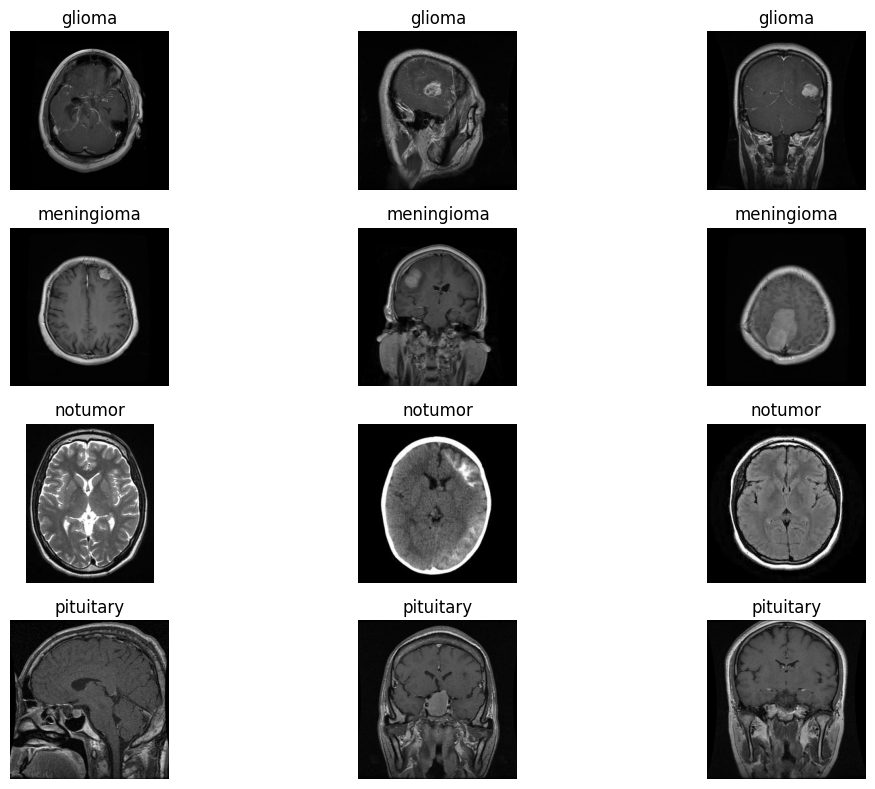

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.groupby("label").sample(n=3, random_state=42)

plt.figure(figsize=(12, 8))

for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.image_path).convert("RGB")

    plt.subplot(4, 3, i)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")

plt.tight_layout()
plt.savefig("figures/day1_sample_images.png", dpi=150)
plt.show()

In [8]:
from pathlib import Path

summary = f"""
# Day 1 Summary - MediScan

## Work Completed

- Google Colab setup completed
- GitHub repo cloned
- Dataset extracted from Google Drive
- Dataset structure checked
- Dataset manifest created
- Class distribution checked
- Sample MRI images visualized

## Dataset Details

Total images: {len(df)}

Classes:
{df['label'].value_counts().to_string()}

## Dataset Type

Brain MRI image classification dataset.

Classes:
- glioma
- meningioma
- notumor
- pituitary
"""

Path("reports/day1_summary.md").write_text(summary)

print(summary)


# Day 1 Summary - MediScan

## Work Completed

- Google Colab setup completed
- GitHub repo cloned
- Dataset extracted from Google Drive
- Dataset structure checked
- Dataset manifest created
- Class distribution checked
- Sample MRI images visualized

## Dataset Details

Total images: 7200

Classes:
label
meningioma    1800
notumor       1800
pituitary     1800
glioma        1800

## Dataset Type

Brain MRI image classification dataset.

Classes:
- glioma
- meningioma
- notumor
- pituitary

